# Исследования рынка общественного питания Москвы

Дата: 21.11.2025

## Цели и задачи проекта

<font color='#777778'>Провести исследовательский анализ рынка общественного питания Москвы, чтобы помоч инвесторам выбрать тип заведения, его местоположение и стратегию развития.
- Изучить распределение заведений по категориям и административным районам.
- Проанализировать соотношение сетевых и несетевых заведений.
- Исследовать колличество посадочных мест и рейтинги заведений.
- Определить популярные сети и их характеристики.
- Изучить зависимости среднего чека от района.
</font>

## Описание данных
Данные с заведениями общественного питания Москвы, составленный на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. 

Информация, размещённая в сервисе Яндекс Бизнес, добавлена пользователями или получена в общедоступных источниках.

Для анализа получены данные о заведениях общественного питания Москвы. Данные состоят из двух датасетов:






Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым: 
0 — заведение не является сетевым;
1 — заведение является сетевым.
- `seats` — количество посадочных мест.

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
- `price` — категория цен в заведении;
- `avg_bill` — хранит среднюю стоимость заказа;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»;
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»;


## Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ:
- Распределение по категориям и районам.
- Соотношение сетевых и несетевых заведений.
- Анализ посадочных мест и рейтингов.
- Топ сетей и их характеристики.
- Зависимость среднего чека от района.
4. Итоговые выводы и рекомендации для инвесторов.



## Загрузка данных и знакомство с ними



Загружаем необходимые библиотеки и датасеты для работы:

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку если она не найдена для расчёта коэффициента корреляции phi_k
try:
    from phik import phik_matrix
except ImportError:
    # Устанавливаем phik если не найден, используя ключ -q для тихой установки
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "phik", "-q"])
    from phik import phik_matrix



In [2]:
#Создаём датафреймы
#таблица, содержащая информацию о заведениях общественного питания
df_ri = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
#таблица, содержащая информацию о среднем чеке
df_rp = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

### Знакомимся с данными из первой таблицы (содержащей информацию о заведениях общественного питания)

Выгрузим информацию о заведениях общественного питания

In [3]:
print ('Выводим первые 5 строк датафрейма, чтобы убедиться, что всё работает правильно:')
print ('')
df_ri.head()

Выводим первые 5 строк датафрейма, чтобы убедиться, что всё работает правильно:



,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
print ('Выводим информацию о датафрейме:')
print ('')
print(df_ri.info())

Выводим информацию о датафрейме:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB
None


**<p style="color: black; background-color: orange;">Вывод:</p>**


Обратим внимание:
- Количество строк 8406 и 9 столбцов. 
- В столбцах `hours` 536 пропусков и `seats` 3611. В остальныхданных пропуски отсутствуют.
- тип данных `object` имеют столбцы `id`, `name`, `address`, `district`, `category`, что соответствует их содержимому.
- `rating`, `seats` имеют тип данных `float64`, `chain` имеет тип данных `int64`, что также соответствует их содержимому.
- `hours` содержит информацию о днях и часах работы, имеет типа данных `object`. Пример содержащейся информации `ежедневно, 10:00–22:00` или `пн-чт 11:00–02:00; пт,сб 11:00–05:00;`. Тип данных наиболее оптимальный, менять не требуется.
- `category` содержит информацию о категории заведений. В дальнейшеме проверим на наличие ошибок в заполнении данных. 

### Знакомимся с данными из второй таблицы (содержащей информацию о среднем чеке)

Выгрузим информацию о среднем чеке в заведениях общепита 

In [5]:
print ('Выводим первые 5 строк датафрейма, чтобы убедиться, что всё работает правильно:')
print ('')
df_rp.head()

Выводим первые 5 строк датафрейма, чтобы убедиться, что всё работает правильно:



,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
print ('Выводим информацию о датафрейме:')
print(df_rp.info())

Выводим информацию о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB
None


**<p style="color: black; background-color: orange;">Вывод:</p>**


Обратим внимание:
- Количество строк 4058 и 5 столбцов. 
- В столбцах `price` 743 пропусков, `avg_bill` 242 пропусков, `middle_avg_bill` 908 пропусков, `middle_coffee_cup` 3523 пропусков. 
- тип данных `object` имеют столбцы `id`, `price`, `avg_bill`, что соответствует их содержимому.
- `middle_avg_bill`, `middle_coffee_cup` имеют тип данных `float64`, что также соответствует их содержимому.

---

### Промежуточный вывод


rest_info.csv: Содержит 8406 заведений с 9 характеристиками (название, категория, адрес, район, график работы, рейтинг, сетевой статус, посадочные места).
rest_price.csv: Содержит 4058 записей с 5 параметрами (ценовая категория, описание среднего чека, числовые оценки чека и кофе).

Данные в целом соответствуют описанию. В rest_price столбцы middle_avg_bill и middle_coffee_cup заполнены частично, что соответствует описанию.

Пропущенные значения:
rest_info:
- seats: 43% пропусков (3611 из 8406).
- hours: 6.4% пропусков (536 из 8406).
rest_price:
- price: 18.3% пропусков (743 из 4058).
- avg_bill: 6% пропусков (3816 из 4058).
- middle_avg_bill: 22.4% пропусков (909 из 4058).
- middle_coffee_cup: 86.8% пропусков (3523 из 4058).

avg_bill содержит неструктурированные данные (например, "Средний счёт: 500–1000 ₽").
hours включает сложные форматы времени работы (например, "пн-чт 11:00–02:00").
В rest_price столбцы с числовыми оценками (middle_avg_bill, middle_coffee_cup) имеют много пропусков

Задачи предобработка:
- Обработать пропуски.
- Для price добавить категорию "не указано".
- Для avg_bill довавим категорию "нет данных".
- Объединить датасеты по id, проверив совпадение ключей.
- Удалить или заполнить строки с пропусками в hours.

### Подготовка единого датафрейма

Присоеденим датасет `df_rp` к `df_ri` и  по столбцу `id`, выбрав левое присоединение. 

In [7]:
df = pd.merge(df_ri, df_rp, on='id', how='left')
print ('Выводим информацию о датафрейме:')
row_count = df.shape[0]
print(df.info())

Выводим информацию о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB
None


**<p style="color: black; background-color: orange;">Вывод:</p>**
Итоговый детефрейм содержит 8406 строк и 13 столбцов. 

Сохраним количество строк в переменную `row_count` для последующего анализа данных, которые были исключены.

## Предобработка данных

**Подготовим данные к исследовательскому анализу:**
- Обработать пропуски.
- Для price добавить категорию "не указано".
- Для avg_bill довавим категорию "нет данных".
- Объединить датасеты по id, проверив совпадение ключей.
- Удалить или заполнить строки с пропусками в hours.

### Изучим корректность типов данных и при необходимости проведим их преобразование.

- тип данных `object` имеют столбцы `id`, `name`, `address`, `district`, `category`,`price`, `avg_bill`. Тип данных `object` в  обычно используется для хранения строковых данных или смешанных типов, которые не могут быть представлены числовыми типами данных. С учетом информации, которая содержится в этих столбцах, тип данных выбран наиболее оптимальный, менять не требуется.
- `hours` содержит информацию о днях и часах работы, имеет типа данных `object`. Пример содержащейся информации `ежедневно, 10:00–22:00` или `пн-чт 11:00–02:00; пт,сб 11:00–05:00;`. Тип данных наиболее оптимальный, менять не требуется.
- `rating`, `seats`, `middle_avg_bill`, `middle_coffee_cup`имеют тип данных `float64`, `chain` имеет тип данных `int64`, что также соответствует их содержимому.

**Вывод: менять тип данных не требуется.**

### Изучим пропущенные значения в данных: 
- посчитаем их количество в каждом столбце датафрейме;
- изучим данные с пропущенными значениями и предположите гипотезы их появления;
- проведим обработку пропущенных значений: заменим пропуски / удалим строки с пропусками / оставить их как есть.

In [8]:
# Подсчитываем количество пропущенных значений для каждого столбца
missing_count = df.isna().sum()

# Вычисляем процент пропущенных значений
missing_percentage = (df.isna().sum() / len(df)) * 100

# Создаём новый датафрейм из полученных данных
missing_data = pd.DataFrame({'Missing Count': missing_count,
    'Missing Percentage': missing_percentage})

# Применяем стиль
styled_missing_data = missing_data.style.background_gradient(cmap='cividis', axis=1).format({
    'Missing Percentage': '{:,.2f}'.format})

# Отображаем результат
display(styled_missing_data)



,Missing Count,Missing Percentage
id,0,0.00
name,0,0.00
category,0,0.00
address,0,0.00
district,0,0.00
hours,536,6.38
rating,0,0.00
chain,0,0.00
seats,3611,42.96
price,5091,60.56


**<p style="color: black; background-color: orange;">Вывод:</p>**
В 6 столбцах есть пропущенные данные: 
- `hours` (6.38%),
- `seats` (42.96%),
- `price` (60.56%),
- `avg_bill` (54.6%),
- `middle_avg_bill` (62.54%),
- `middle_coffee_cup` (93.64%)	

**В собранных данных обнаружено значительное количество пропусков, достигающее до 93% в отдельных колонках. Это вызывает сомнения относительно надёжности и однородности источников данных. Существует вероятность, что данные были извлечены из различных источников, в которых определённые блоки информации отсутствовали в одних источниках и присутствовали в других.**

Есть несколько вариантов обработки пропусков:
- Удаление пропусков: можно удалить строки или столбцы с пропусками. Это просто, но может привести к потере большого количества данных, если пропуски встречаются часто.
- Заполнение средними значениями (импутация): пропуски заменяются средними значениями по столбцу или строке. Это помогает сохранить объём данных, но может исказить распределение.
- Заполнение медианой или модой: аналогично заполнению средними значениями, но использует медиану или моду, что может быть более подходящим для некоторых типов данных.
- Прогнозирование пропусков: использование моделей машинного обучения для прогнозирования пропущенных значений на основе других данных. Это более сложный метод, но может дать хорошие результаты.
- Заполнение постоянным значением: пропуски заполняются заранее определённым значением, например, нулём или другим значением, которое имеет смысл в контексте данных.
- Использование специальных алгоритмов: некоторые алгоритмы, такие как случайные леса или градиентный бустинг, могут работать с пропусками без необходимости их предварительного заполнения.


**В результате анализа было обнаружено, что замена значительной части данных с использованием медианы или среднего значения может привести к искажению реальной картины. Поэтому, оценив количество пропусков и оставшихся данных, было принято решение сохранить пропуски и перейти к выполнению аналитических задач.**


In [9]:
# Заполним пропуски hours, avg_bill. Это необходимо для проведения анализа в следуюбщих блоках работы.
df['avg_bill'] = df['avg_bill'].fillna('нет данных')
df['hours'] = df['hours'].fillna('Нет информации')

### Проверим данные на явные и неявные дубликаты.

In [10]:
# Проверяем полные дубликаты в датафрейме
df.duplicated().sum()

np.int64(0)

В датафрейме нет полных дубликатов строк.

Проверим `id`. Значения по `id` должны быть уникальными.

In [11]:
# Проверяем наличие дубликатов в столбце 'id'
duplicates = df['id'].duplicated()
print(f'Выведем количество дубликатов в столбце id:',duplicates.sum())
# Выводим уникальные значения.
print(f'Выведем количество уникальных значений в столбце id:',df['id'].nunique())

Выведем количество дубликатов в столбце id: 0
Выведем количество уникальных значений в столбце id: 8406


Проверим `name`:

In [12]:
# Проверяем наличие дубликатов в столбце 'name'
duplicates = df['name'].duplicated()
print(f'Выведем количество дубликатов в столбце name:',duplicates.sum())
# Выводим уникальные значения.
print(f'Выведем количество уникальных значений в столбце name:',df['name'].nunique())
print("Посмотрим, какие данные есть в 'name' и сколько раз встречались:")
value_counts = df['name'].value_counts().sort_index()
print(value_counts)

Выведем количество дубликатов в столбце name: 2792
Выведем количество уникальных значений в столбце name: 5614
Посмотрим, какие данные есть в 'name' и сколько раз встречались:
name
#КешбэкКафе                    1
+39 Pizzeria Mozzarella bar    1
1 Этаж                         1
1-я Креветочная                1
10 Идеальных Пицц              3
                              ..
Яръ                            1
Ясмин                          1
Ясно                           1
Яуза                           1
ночной Баку                    1
Name: count, Length: 5614, dtype: int64


Приведем все данные к нижнему регистру, чтобы исключить возможные дубликаты:

In [13]:
df['name'] = df['name'].str.lower()
duplicates = df['name'].duplicated()
print(f'Выведем количество дубликатов в столбце name:',duplicates.sum())
# Выводим уникальные значения.
print(f'Выведем количество уникальных значений в столбце name:',df['name'].nunique())

Выведем количество дубликатов в столбце name: 2894
Выведем количество уникальных значений в столбце name: 5512


**После приведения всех названия к одному регистру, количество явных буликатов увечилось.**

Проверим `category`:

In [14]:
# Проверяем наличие дубликатов в столбце 'category'
duplicates = df['category'].duplicated()
unique_values = df['category'].unique()
unique_values = sorted(unique_values)
print(f'Выведем количество дубликатов в столбце category:',duplicates.sum())
print(f'Выведем количество уникальных значений в столбце category:',df['category'].nunique())
print('')
print("Выведем, сколько раз встречались все уникальные значения в 'category':")
value_counts = df['category'].value_counts().sort_index()
print(value_counts)


Выведем количество дубликатов в столбце category: 8398
Выведем количество уникальных значений в столбце category: 8

Выведем, сколько раз встречались все уникальные значения в 'category':
category
бар,паб             765
булочная            256
быстрое питание     603
кафе               2378
кофейня            1413
пиццерия            633
ресторан           2043
столовая            315
Name: count, dtype: int64


Проверим `address`:

In [15]:
# Проверяем наличие дубликатов в столбце 'address'
duplicates = df['address'].duplicated()
print(f'Выведем количество дубликатов в столбце address:',duplicates.sum())
# Выводим уникальные значения.
print(f'Выведем количество уникальных значений в столбце address:',df['address'].nunique())
print("Посмотрим, какие данные есть в 'address' и сколько раз встречались:")
value_counts = df['address'].value_counts().sort_index()
print(value_counts)

Выведем количество дубликатов в столбце address: 2653
Выведем количество уникальных значений в столбце address: 5753
Посмотрим, какие данные есть в 'address' и сколько раз встречались:
address
Москва, 1-й Автозаводский проезд, 5        1
Москва, 1-й Балтийский переулок, 3/25      1
Москва, 1-й Варшавский проезд, 1Ас9        1
Москва, 1-й Вешняковский проезд, 15        1
Москва, 1-й Волоколамский проезд, 10       1
                                          ..
Москва, шоссе Энтузиастов, 86, стр. 6      1
Москва, шоссе Энтузиастов, 86, стр. 7      1
Москва, шоссе Энтузиастов, 86А, корп. 3    1
Москва, шоссе Энтузиастов, с2              1
Москва, № 7                                1
Name: count, Length: 5753, dtype: int64


Проверим на наличие полных дубликатов для стобцов `name`, `address`. Сразу приведем все данные в `address` к одному регистру (нижнему).

In [16]:
df['address'] = df['address'].str.lower()
df['name_address'] = df['name'] + ' ' + df['address']
duplicates = df['name_address'].duplicated().sum()
print(f"Количество полных дубликатов: {duplicates}")

Количество полных дубликатов: 4


In [17]:
#Удалим найденные дубликаты
df = df.drop_duplicates(subset='name_address', keep='first')

Проверим `district`:

In [18]:
# Проверяем наличие дубликатов в столбце 'district'
duplicates = df['district'].duplicated()
unique_values = df['district'].unique()
unique_values = sorted(unique_values)
print(f'Выведем количество дубликатов в столбце district:',duplicates.sum())
# Выводим уникальные значения.
print(f'Выведем количество уникальных значений в столбце district:',df['district'].nunique())
print('')
print("Уникальные значения в столбце 'district':")
print("Выведем, сколько раз встречались все уникальные значения в 'district':")
value_counts = df['district'].value_counts().sort_index()
print(value_counts)

Выведем количество дубликатов в столбце district: 8393
Выведем количество уникальных значений в столбце district: 9

Уникальные значения в столбце 'district':
Выведем, сколько раз встречались все уникальные значения в 'district':
district
Восточный административный округ            798
Западный административный округ             850
Северный административный округ             898
Северо-Восточный административный округ     890
Северо-Западный административный округ      409
Центральный административный округ         2242
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Южный административный округ                892
Name: count, dtype: int64


Проверка для `hours`, `rating`, `chain`, `seats`, `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup` на дубликаты не требуется, так как это количественные данные.

**Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:**
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [19]:
print("Посмотрим, какие данные есть в 'hours':")
value_counts = df['hours'].value_counts().sort_index()
print(value_counts)

Посмотрим, какие данные есть в 'hours':
hours
Нет информации                                                       536
вт 08:30–17:00; ср,чт 12:00–20:30; пт 08:30–17:00; сб 09:00–16:30      1
вт 13:00–21:00; ср 11:00–20:00; чт 13:00–21:00; пт-вс 11:00–20:00      1
вт,чт 10:00–18:00                                                      1
вт,чт,пт,сб,вс 08:00–23:00                                             1
                                                                    ... 
ср-пт 15:00–00:00                                                      1
чт 18:00–00:00; пт,сб 15:00–06:00; вс 15:00–00:00                      1
чт 20:00–02:00; пт,сб 20:00–06:00                                      1
чт круглосуточно, перерыв 10:00–20:00; сб круглосуточно                1
чт-вс 20:00–06:00                                                      1
Name: count, Length: 1306, dtype: int64


In [20]:
# Замена пропущенных значений 
df['is_24_7'] = df['hours'].apply(lambda x: True if 'ежедневно' in x and 'круглосуточно' in x else False)
print(f'Количество заведений, которые работают 24/7: {df["is_24_7"].sum()}')
# Фильтруем датафрейм по условию is_24_7 == True
filtered_df = df[df['is_24_7'] == True]
print('')
# Выводим уникальные значения столбца hours
print('Проверим, что данные были отобранные правильно:')
unique_values = filtered_df['hours'].unique()
print("Уникальные значения для столбца hours, где is_24_7 == True:")
print(unique_values)

Количество заведений, которые работают 24/7: 730

Проверим, что данные были отобранные правильно:
Уникальные значения для столбца hours, где is_24_7 == True:
['ежедневно, круглосуточно']


---

### Промежуточный вывод

На этом предобработка завершена. Предоставленные данные хорошего качества и требуют не так много действий по предобработке. Итоги предобработки:


- Полных дубликатов строчек и `id` не обнаружено.
- После приведения к одному регистру столбцов стобцов `name` и `address` выявлено и удалено 4 дубликата.
- В данных остальных данных дубликаты встречаются, но это допустимо. 
- Ошибок в категорийных данных не обнаружено.
- Заполнены пропуски hours, avg_bill
- Создан столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно.

In [21]:
#Посчитаем количество отфильтрованных данных, после удаления.
print(f"Количество строк до удаления: {row_count}")
row_count_1= row_count -df.shape[0]
print(f"количество удалённых строк: {row_count_1} или {row_count_1 / row_count * 100:.2f}%")
print(f"Количество строк после удаления: {df.shape[0]}")

Количество строк до удаления: 8406
количество удалённых строк: 4 или 0.05%
Количество строк после удаления: 8402


## Исследовательский анализ данных
Проведем исследовательский анализ исходных данных.

При исследовании данных используем визуализации. 

В конце обобщим результаты, выделив, самые важные.

---

### Задача 1

**Какие категории заведений представлены в данных? Исследуем количество объектов общественного питания по каждой категории.**

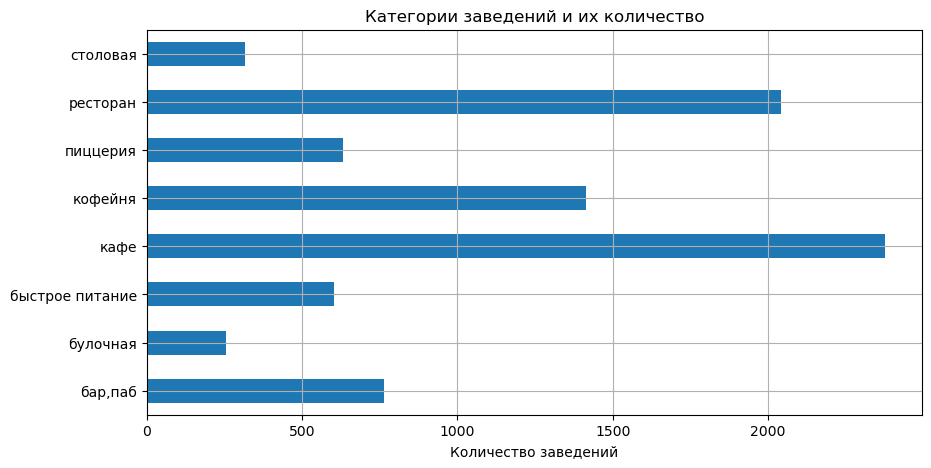

Выведем данную информацию в виде таблицы
                 Количество  Доля
category                         
кафе                   2376  28.3
ресторан               2042  24.3
кофейня                1413  16.8
бар,паб                 764   9.1
пиццерия                633   7.5
быстрое питание         603   7.2
столовая                315   3.7
булочная                256   3.0


In [22]:
plt.figure(figsize=(10, 5))

# Строим столбчатую диаграмму
ax = df['category'].value_counts().sort_index().plot(
    kind='barh',
    rot=0,
    legend=False,
    title=f'Категории заведений и их количество'
)

plt.xlabel('Количество заведений')
plt.ylabel('')
plt.grid()

plt.show()

print('Выведем данную информацию в виде таблицы')
category_counts = df['category'].value_counts()
total_count = len(df['category'])

# Создаем DataFrame с количеством и относительными величинами
result_df = pd.DataFrame({
    'Количество': category_counts.values,
    'Доля': (category_counts / total_count) * 100
})
result_df['Доля'] = result_df['Доля'].round(1)
print(result_df)


**<p style="color: black; background-color: orange;">Вывод:</p>**
Топ-3 заведений, которые чаще всего встречаются в городе:
- `кафе` - 2378, 28,3%
- `рестрон` - 2043, 24,3%
- `кофейня` - 1413, 16,8%


---

### Задача 2

**Какие административные районы Москвы присутствуют в данных?**

**Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.**

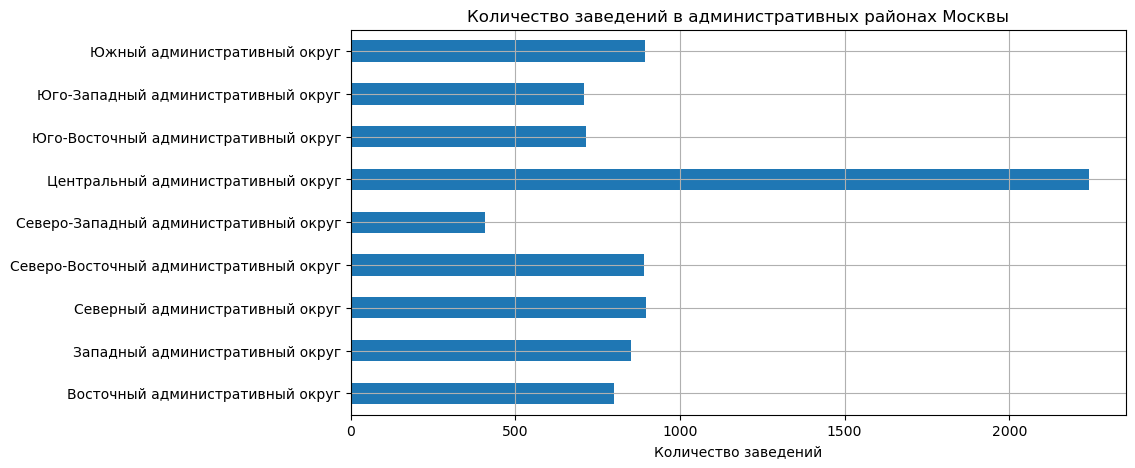

Выведем данную информацию в виде таблицы
                                         Количество  Доля
district                                                 
Центральный административный округ             2242  26.7
Северный административный округ                 898  10.7
Южный административный округ                    892  10.6
Северо-Восточный административный округ         890  10.6
Западный административный округ                 850  10.1
Восточный административный округ                798   9.5
Юго-Восточный административный округ            714   8.5
Юго-Западный административный округ             709   8.4
Северо-Западный административный округ          409   4.9


In [23]:
#Исследуем распределение количества заведений по административным районам Москвы
plt.figure(figsize=(10, 5))

# Строим столбчатую диаграмму
ax = df['district'].value_counts().sort_index().plot(
    kind='barh',
    rot=0,
    legend=False,
    title=f'Количество заведений в административных районах Москвы'
)

# Настраиваем оформление графика
plt.xlabel('Количество заведений')
plt.ylabel('')
plt.grid()
plt.show()

print('Выведем данную информацию в виде таблицы')
category_counts = df['district'].value_counts()
total_count = len(df['district'])

# Создаем DataFrame с количеством и относительными величинами
result_df = pd.DataFrame({
    'Количество': category_counts.values,
    'Доля': (category_counts / total_count) * 100
})
result_df['Доля'] = result_df['Доля'].round(1)
print(result_df)

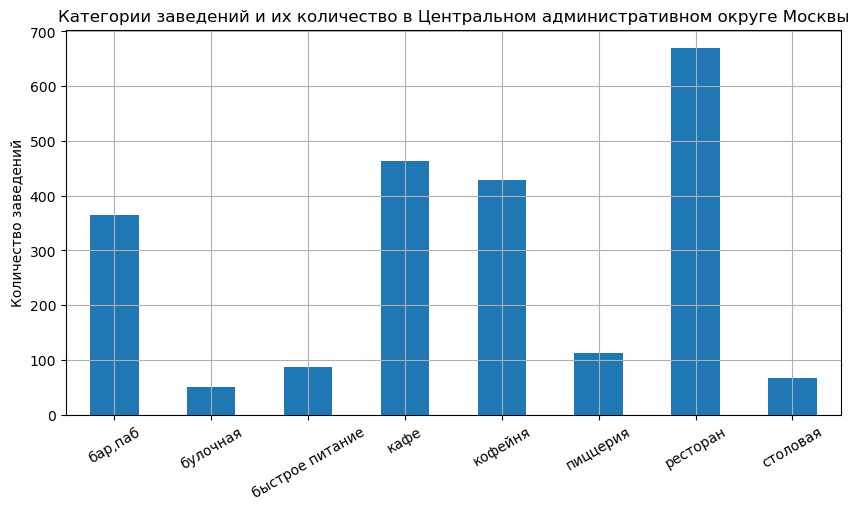

                 Количество  Доля
category                         
ресторан                670  29.9
кафе                    464  20.7
кофейня                 428  19.1
бар,паб                 364  16.2
пиццерия                113   5.0
быстрое питание          87   3.9
столовая                 66   2.9
булочная                 50   2.2


In [24]:
#Исследуем распределение заведений каждой категории в Центральном административном округе Москвы
plt.figure(figsize=(10, 5))
filtered_df = df[df['district'] == 'Центральный административный округ']

# Строим столбчатую диаграмму
ax = filtered_df['category'].value_counts().sort_index().plot(
    kind='bar',
    rot=30,
    legend=False,
    title=f'Категории заведений и их количество в Центральном административном округе Москвы'
)

# Настраиваем оформление графика
plt.xlabel('')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

category_counts = filtered_df['category'].value_counts()
total_count = len(filtered_df['category'])
# Создаем DataFrame с количеством и относительными величинами
result_df = pd.DataFrame({
    'Количество': category_counts.values,
    'Доля': (category_counts / total_count) * 100
})
result_df['Доля'] = result_df['Доля'].round(1)
print(result_df)

**<p style="color: black; background-color: orange;">Вывод:</p>**
**Задача 1**: 
- в датасете присутствуют 9 административных районов
- больше всего заведений в `Центральном административном округе` - 26.7%
- наименьшее количество заведений в `Северо-Западном административном округе`  - 4.87%;

**Задача 2**:

в `Центральном административном округе` наиболее популярная категория заведений - `рестораны` (29,9%) и `кафе` (20,7%)

При этом по Москве обратная ситуация: 1-ое место - `кафе` (28,3%), а `рестораны` (24,3%) на 2-ом месте.

### Задача 3

**Изучить соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.**

**Ответить на вопросы:**
- **Каких заведений больше — сетевых или несетевых?**
- **Какие категории заведений чаще являются сетевыми?**

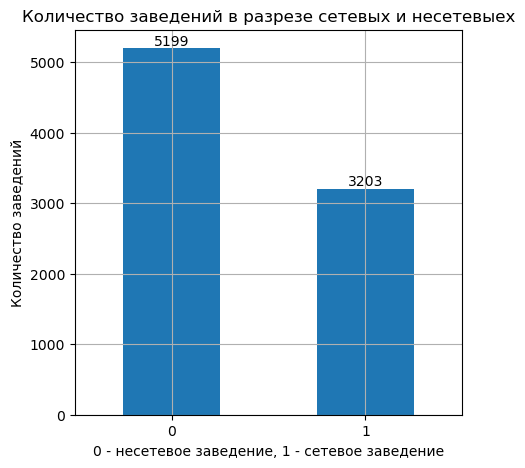

       Количество  Доля
chain                  
0            5199  61.9
1            3203  38.1


In [25]:
#Исследуем наличие сетевых и несетевых заведений
plt.figure(figsize=(5, 5))

# Строим столбчатую диаграмму
ax = df['chain'].value_counts().sort_index().plot(
    kind='bar',
    rot=0,
    legend=False,
    title=f'Количество заведений в разрезе сетевых и несетевыех'
)

# Настраиваем оформление графика
plt.xlabel('0 - несетевое заведение, 1 - сетевое заведение')
plt.ylabel('Количество заведений')
plt.grid()
# Добавляем значения на график
for container in ax.containers:
    ax.bar_label(container)
plt.show()

category_counts = df['chain'].value_counts()
total_count = len(df['chain'])
# Создаем DataFrame с количеством и относительными величинами
result_df = pd.DataFrame({
    'Количество': category_counts.values,
    'Доля': (category_counts / total_count) * 100
})
result_df['Доля'] = result_df['Доля'].round(1)
print(result_df)

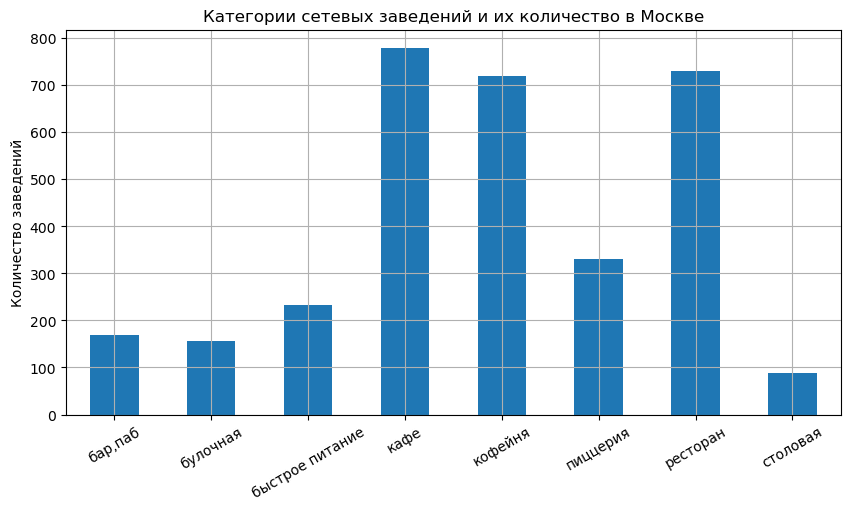

                 Количество  Доля
category                         
кафе                    779  24.3
ресторан                729  22.8
кофейня                 720  22.5
пиццерия                330  10.3
быстрое питание         232   7.2
бар,паб                 168   5.2
булочная                157   4.9
столовая                 88   2.7


In [26]:
#Исследуем распределение заведений каждой категории в Центральном административном округе Москвы
plt.figure(figsize=(10, 5))
filtered_df = df[df['chain'] == 1]

# Строим столбчатую диаграмму
ax = filtered_df['category'].value_counts().sort_index().plot(
    kind='bar',
    rot=30,
    legend=False,
    title=f'Категории сетевых заведений и их количество в Москве'
)

# Настраиваем оформление графика
plt.xlabel('')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

category_counts = filtered_df['category'].value_counts()
total_count = len(filtered_df['category'])
# Создаем DataFrame с количеством и относительными величинами
result_df = pd.DataFrame({
    'Количество': category_counts.values,
    'Доля': (category_counts / total_count) * 100
})
result_df['Доля'] = result_df['Доля'].round(1)
print(result_df)

**<p style="color: black; background-color: orange;">Вывод:</p>**
**Задача 1:** Несетевых заведений больше: 5201 против 3205 сетевых.

**Задача 2:** Больше всего среди сетевых заведений: `кафе` (24,3%), а меньше всего `столовых` (2,7%)

---

### Задача 4

**Исследуем количество посадочных мест в заведениях:**
- **Встречаются ли в данных аномальные значения или выбросы?**
- **Если да, то с чем они могут быть связаны?**
- **Приведем для каждой категории заведений наиболее типичное для него количество посадочных мест.**


**Выведем общую информацию:**

In [27]:
# Общие данные по столбцу seats
df['seats'].describe()

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

В среднем 108 посадочных мест, медиана 75 мест. Большая разница между средним значением и медианой говорит о выбросах. А максимальное значение в 1288 посадочных мест может говорить об ошибке в данных. 

In [28]:
sorted_df = df.sort_values(by='seats', ascending=False)
print(sorted_df[['name', 'category', 'seats', 'chain']].head(20))

                    name         category   seats  chain
6524           ян примус         ресторан  1288.0      1
6574              мюнгер         пиццерия  1288.0      1
6518         delonixcafe         ресторан  1288.0      0
6684     пивной ресторан          бар,паб  1288.0      0
6690      японская кухня         ресторан  1288.0      1
6641    one price coffee          кофейня  1288.0      1
6658              гудбар          бар,паб  1288.0      0
6771               точка             кафе  1288.0      1
6807  loft-cafe академия             кафе  1288.0      0
6838  alternative coffee          кофейня  1288.0      0
6808        яндекс лавка         ресторан  1288.0      1
4231  рестобар argomento         столовая  1200.0      0
2713         ваня и гоги          бар,паб  1040.0      0
2966            матрешка             кафе  1040.0      0
2722           маргарита  быстрое питание  1040.0      1
2770         шоколадница          кофейня  1040.0      1
4180              eataly       

Видим, что есть кафе, бары и паб, кофейни на более 1000 посадочных мест, что весьма странно. Большое число заведений с завышенным и одинаковым количеством посадочных мест говорит о явной ошибке. Из-за нехватки данных невозможно сказать, на каком количестве мест была допущена ошибка и есть ли ошибки по другим данным.

**Проанализируем также заведения, в которох 0 посадочных мест.**

In [29]:
# Посчитаем, сколько заведений, в котороых 0 посадочных мест:
print(f'Количество заведений, в которых 0 посадочных мест: {len(df[df['seats'] == 0])}')
df_without_seats = df[df['seats'] == 0]['category'].value_counts()
print(df_without_seats)


Количество заведений, в которых 0 посадочных мест: 136
category
кафе               44
кофейня            24
ресторан           20
быстрое питание    18
булочная           11
пиццерия           10
столовая            5
бар,паб             4
Name: count, dtype: int64


Как и с максимальным количеством мест, видим, что присуствтуют данные с 0 мест для посадки. Возможно это места, где заказы можно сделать удаленно или на вынос, поэтому у них отсутствуют посадочные места. 

**Оценим количество мест по разным категориям через медианное значение:**

In [30]:
df_1 = df.groupby('category')['seats'].median().sort_values().round(0)
print()
print(df_1)


category
булочная           50.0
пиццерия           55.0
кафе               60.0
быстрое питание    65.0
столовая           76.0
кофейня            80.0
бар,паб            82.0
ресторан           86.0
Name: seats, dtype: float64


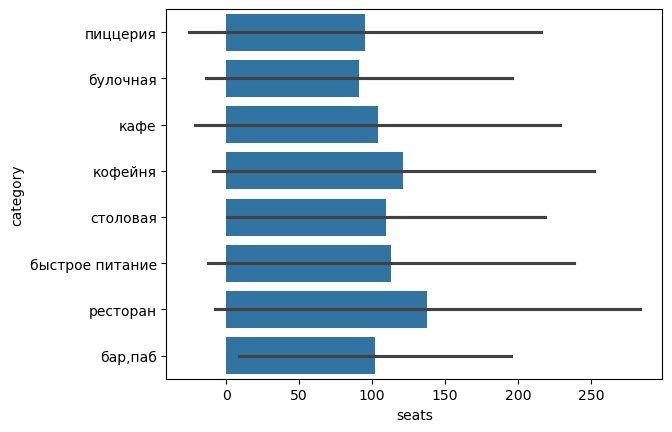

In [31]:
sns.barplot(data=filtered_df, x='seats', y='category', errorbar='sd')
plt.show()

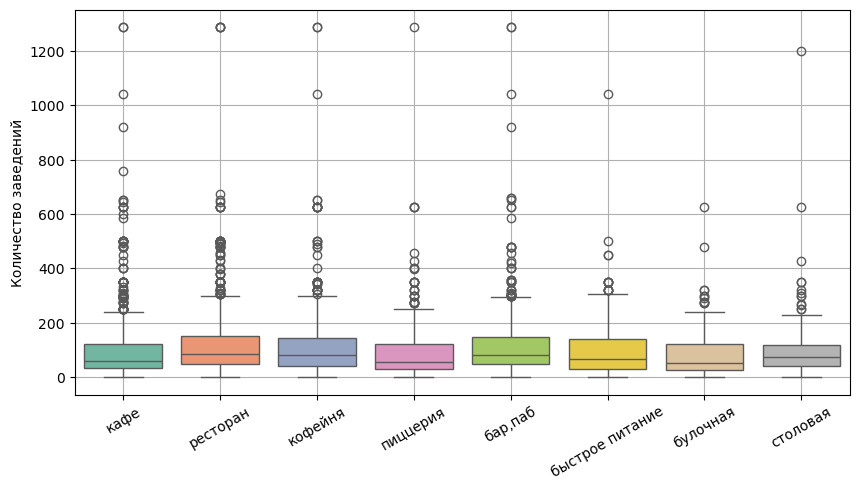

In [32]:
#посмотрим, как много выбросов в данных
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x='category',
    y='seats',
    hue='category',
    palette='Set2'
)
# Настраиваем оформление графика
plt.xlabel('')
plt.ylabel('Количество заведений')
plt.grid()
plt.xticks(rotation=30)
plt.show()


**<p style="color: black; background-color: orange;">Вывод:</p>**
- Всего 4795 заведений, для которых указано количество посадочных мест, то есть данные присутствуют только для 57% заведений.
- 136 заведений не имеют посадочные места. При этом в каждой категории есть такие заведения. Возможно это означает ошибку в данных или это места, где заказы можно сделать удаленно или на вынос, поэтому у них отсутствуют посадочные места.
- В данных присутствуют ошибки, так как есть кафе, бары и паб, кофейни на более 1000 посадочных мест, что весьма странно. Это говорит о наличие явных ошибок, но не из-за отсутствия данных невозможно точно оценить, есть ли ошибки по количеству посадочных мест в целом по датасету и каким образом их выявить.
- В среднем 108 посадочных мест, медиана 75 мест. Стандартного отклонения 122. Всего говорит о болших выбросах.
- На основе медианных значений, больше 80 посадочных мест имеют в `ресторан`, `бар,паб`, `кофейня`, меньше всего для `булочная` (50) и `пиццерия` (55).
- Для всех данныъ по категориям заведений характерны сильные и частые выбросы. Особенно много для `кафе`, `рестронов` и `бар,паб`.

---

### Задача 5

- **Исследуем рейтинг заведений.**
- **Визуализируем распределение средних рейтингов по категориям заведений.**
- **Сильно ли различаются усреднённые рейтинги для разных типов общепита?**

In [33]:
# Общие данные по столбцу rating
df['rating'].describe()

count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

**Анализ заведений общественного питания Москвы по рейтингу в разрезе категорий заведений**


In [34]:
# Создадим таблицу с количеством заведений в разрезе категорий и административных округов
df_rating = pd.pivot_table(
    df, 
    index='category', 
    values='rating', 
    aggfunc=['mean', 'median'])

# Переименовываем столбцы для более понятного представления данных
df_rating.columns = ['Средний', 'Медиана']
df_rating = df_rating.round(2)
# Преобразуем индекс в обычный столбец и сортируем по среднему рейтингу в порядке убывания
df_rating = df_rating.sort_values('Средний', ascending=False).reset_index()
(df_rating.style
          .background_gradient(cmap='cividis', axis=0)
          .format({'Средний': '{:.2f}', 'Медиана': '{:.2f}'})
)

,category,Средний,Медиана
0,"бар,паб",4.39,4.40
1,пиццерия,4.30,4.30
2,ресторан,4.29,4.30
3,кофейня,4.28,4.30
4,булочная,4.27,4.30
5,столовая,4.21,4.30
6,кафе,4.12,4.20
7,быстрое питание,4.05,4.20


**<p style="color: black; background-color: orange;">Вывод:</p>**
- средний рейтинг для всех заведений: 4,2
- наибольший рейтинг имеют заведения `бар,паб`, а наименьший `кафе` и `быстрое питание` , рейтинги других заведений примерно одинаковые.
- для заведений `столовая`, `кафе`, `быстрое питание` характерно большие различия между значениями среднего и медианы.
- из-за почти одинакового рейтинга в районе 4-4,4 трудно определеить, что может показывать рейтинг. Вероятно в выборку изначально попадали именно такие заведения, с высоким рейтингом. 

---

### Задача 6

**Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений?** 

**Построим и визуализируем матрицу корреляции рейтинга заведения с разными данными:** 
- категория 
- положение (административный район Москвы)
- статус сетевого заведения
- количество мест
- ценовая категория
- является ли заведения круглосуточным
- Выберем самую сильную связь и проверем её.

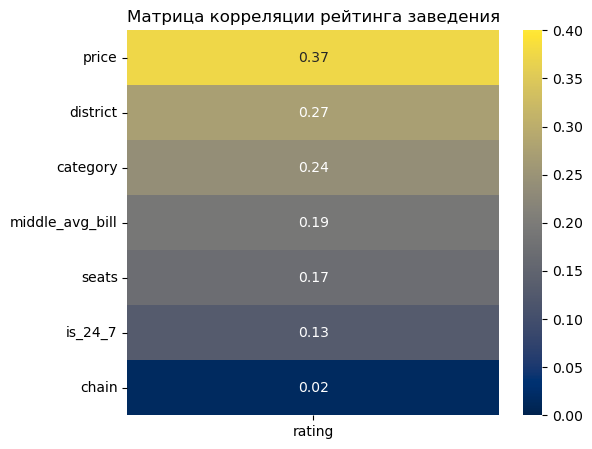

In [35]:
# Выбираем только релевантные столбцы
df_1 = ['category', 'district', 'chain', 'seats', 'rating', 'price', 'middle_avg_bill', 'is_24_7']

# Удаляем строки с пропусками в ключевых столбцах
df_2 = df[df_1].dropna(subset=['rating', 'price', 'middle_avg_bill'])

# Явно указываем числовые столбцы
interval_cols = ['seats', 'middle_avg_bill']

# Вычисляем матрицу pin_k
corr_matrix = df_2.phik_matrix(
    interval_cols=interval_cols,
    drop_overflow=False)

# Извлекаем корреляции с рейтингом
rating_corr = corr_matrix[['rating']].drop('rating', axis=0).sort_values(by='rating', ascending=False)

plt.figure(figsize=(6, 5))

# Построим матрицу с использованием цветовых градиентов
sns.heatmap(rating_corr, 
            annot=True, 
            cmap='cividis', 
            vmin=0, 
            vmax=0.4,
            fmt=".2f")
plt.title('Матрица корреляции рейтинга заведения')
plt.show()

Изучим как `рейтинг` зависит от `ценовой категории`:

In [36]:
#Сгруппируем таблицу и изучим средний рейтинг от ценовой категории
df.groupby('price')['rating'].mean().sort_values(ascending=False).round(2)

price
высокие          4.44
выше среднего    4.39
средние          4.30
низкие           4.17
Name: rating, dtype: float64

In [37]:
#Посмотрим, какая категория заведения имеет самый высокий рейтинг 
df.groupby('category')['rating'].mean().sort_values(ascending=False).round(2)


category
бар,паб            4.39
пиццерия           4.30
ресторан           4.29
кофейня            4.28
булочная           4.27
столовая           4.21
кафе               4.12
быстрое питание    4.05
Name: rating, dtype: float64

In [38]:
#Посмотрим, как ценовая категория в разрезе категории заведений влияет на рейтинг:
df_pivot = pd.pivot_table(
    df,
    index='category',  # категории заведений по вертикали
    columns='price',   # ценовые категории по горизонтали
    values='rating',   # значения для усреднения
    aggfunc='mean'     # функция агрегирования — среднее значение
)
# Переименовываем столбцы для более понятного представления данных
df_pivot.columns = ['Высокая', 'Выше ср.','Низкие','Средние']
df_pivot = df_pivot.round(2)
(df_pivot.style
          .background_gradient(cmap='plasma', axis=0)
          .format({'Высокая': '{:.2f}', 'Выше ср.': '{:.2f}', 'Низкие': '{:.2f}', 'Средние': '{:.2f}', }))

,Высокая,Выше ср.,Низкие,Средние
category,,,,
"бар,паб",4.49,4.43,3.90,4.41
булочная,4.40,4.35,4.27,4.18
быстрое питание,4.20,4.28,3.98,4.21
кафе,3.98,4.40,4.03,4.24
кофейня,4.44,4.33,4.29,4.33
пиццерия,4.45,4.30,4.22,4.31
ресторан,4.47,4.37,4.18,4.32
столовая,4.20,4.00,4.19,4.28


**<p style="color: black; background-color: orange;">Вывод:</p>**
- Самая высокая корреляция рейтинга наблюдается с ценовой категорией.
- Потенциальным посетителям заведений не важно, входит ли заведение в какую то сеть или нет
- Чем выше ценовая категория, тем выше средний рейтинг заведения
- наибольший рейтинг имеют заведения `бар, паб`, а наименьший `кафе` и `быстрое питание` , рейтинги других заведений примерно одинаковые.
- рейтинг выше `4.0` наблюдается для следующий заведений:
  - **Высокие цены:** `бар`, `паб, кофейня`, `пиццерия`, `ресторан`
  - **Цены выше средних:** `бар, паб`, `кафе`
  - **Средние цены:** `бар, паб`
  - **Низкие цены:** нет зведений с рейтингом выше 4.4, но самый высокий рейтинг имеют `кофейня`, `пиццерия`, `ресторан`
- `бар, паб` есть почти во всех ценовых категориях с высоким рейтингом, также можно выделить `пиццерия` на втором месте по рейтингу. Для `пиццерий` рейтинг меньше зависит от ценовой категории.
  

---

### Задача 7

**Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве (Под популярностью понимается количество заведений этой сети в регионе).**

**Посчитаем значения среднего рейтинга.**

**Ответим на вопрос: к какой категории заведений они относятся?**

In [39]:
df_1 = df.loc[df['chain'] == True].groupby(['name', 'category']).agg({
    'name': 'count',
    'rating': 'mean'
})
df_1.columns = ['count', 'mean_rating']
df_1 = df_1.reset_index()

top_15 = df_1.sort_values(by='count', ascending=False).head(15).reset_index(drop=True)
top_15['mean_rating'] = top_15['mean_rating'].round(2)
top_15.columns = ['Назввание сети', 'Категория','Количество заведений','Средний рейтинг']

top_15.style.background_gradient(cmap='mako_r', axis=0).format({'Средний рейтинг': '{:.2f}'})


,Назввание сети,Категория,Количество заведений,Средний рейтинг
0,шоколадница,кофейня,119,4.18
1,домино'с пицца,пиццерия,76,4.17
2,додо пицца,пиццерия,74,4.29
3,one price coffee,кофейня,71,4.06
4,яндекс лавка,ресторан,69,3.87
5,cofix,кофейня,65,4.08
6,prime,ресторан,49,4.11
7,кофепорт,кофейня,42,4.15
8,кулинарная лавка братьев караваевых,кафе,39,4.39
9,теремок,ресторан,36,4.11


**<p style="color: black; background-color: orange;">Вывод:</p>**
- Шоколоданица - самое распространенное заведение, но имееь относительно невысокий рейтинг
- Сетевые заведения с самым высоким рейтингом `Кулинарная лавка братьев караваевых` (кафе), `Буханка` (булочная) и `Кофемания` (кофейня).

---

### Задача 8

**Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы.**

**Проанализируем цены в Центральном административном округе и других.**

**Ответим на вопрос: как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.**


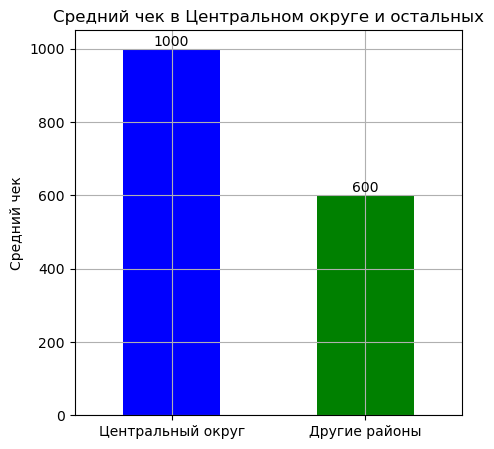

In [40]:
central_avg = df[df['district'] == 'Центральный административный округ']['middle_avg_bill'].median()
non_central_avg = df[df['district'] != 'Центральный административный округ']['middle_avg_bill'].median()

data = pd.Series([central_avg, non_central_avg], index=['Центральный округ', 'Другие районы'])

plt.figure(figsize=(5, 5))
ax = data.plot(
    kind='bar', 
    color=['blue', 'green'],
    rot=0) 

# Добавляем значения на график
for container in ax.containers:
    ax.bar_label(container)

plt.title('Средний чек в Центральном округе и остальных')
plt.ylabel('Средний чек')
plt.grid()
plt.show()


**<p style="color: black; background-color: orange;">Вывод:</p>**
Чем ближек центру, тем выше чек. А именно на 40%.

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

**1. Категории заведений:**
- Кафе, рестораны и кофейни составляют более 70% рынка.
- Столовые и бары занимают нишевые позиции (4.9% и 5.5%).

**2. Распределение по районам:**
В датасете присутствуют 9 административных районов. Больше всего заведений в Центральном административном округе - 26.7%
Наименьшее количество заведений в Северо-Западном административном округе - 4.87%. 
В Центральном административном округе наиболее популярная категория заведений - рестораны (29,9%) и кафе (20,7%). При этом по Москве обратная ситуация: 1-ое место - `кафе` (28,3%), а `рестораны` (24,3%) на 2-ом месте.

**3. Сетевые vs несетевые:**
- Несетевых заведений больше: 5201 против 3205 сетевых.
- Больше всего среди сетевых заведений: кафе (24,3%), а меньше всего столовых (2,7%)

**4. Посадочные места:**
- Всего 4795 заведений, для которых указано количество посадочных мест, то есть данные присутствуют только для 57% заведений.
- 136 заведений не имеют посадочные места. При этом в каждой категории есть такие заведения. Возможно это означает ошибку в данных или это места, где заказы можно сделать удаленно или на вынос, поэтому у них отсутствуют посадочные места.
- В данных присутствуют ошибки, так как есть `кафе, `бары и паб`, `кофейни` на более 1000 посадочных мест, что весьма странно. Это говорит о наличие явных ошибок, но не из-за отсутствия данных невозможно точно оценить, - есть ли ошибки по количеству посадочных мест в целом по датасету и каким образом их выявить.
- В среднем 108 посадочных мест, медиана 75 мест. Стандартного отклонения 122. Всего говорит о болших выбросах.
- В среднем, больше всего посадочных мест в бар, паб, меньше всего для булочная.

**5. Рейтинги:**
- средний рейтинг для всех заведений: 4,2
- наибольший рейтинг имеют заведения `бар, паб`, а наименьший `кафе` и `быстрое питание` , рейтинги других заведений примерно одинаковые.
- для заведений `столовая`, `кафе`, `быстрое питание` характерно большие различия между значениями среднего и медианы.
- из-за почти одинакового рейтинга в районе 4-4,4 трудно определеить, что может показывать рейтинг. Вероятно в выборку изначально попадали именно такие заведения, с высоким рейтингом.

**7. Корреляции:**
- Самая высокая корреляция рейтинга наблюдается с ценовой категорией, приэтом отрицательной коррекляции не обнаружено.
- Потенциальным посетителям заведений не важно, входит ли заведение в какую то сеть или нет
- Чем выше ценовая категория, тем выше средний рейтинг заведения
- наибольший рейтинг имеют заведения `бар, паб`, а наименьший `кафе` и `быстрое питание` , рейтинги других заведений примерно одинаковые.
- рейтинг выше `4.0` наблюдается для следующий заведений:
  - **Высокие цены:** `бар`, `паб, кофейня`, `пиццерия`, `ресторан`
  - **Цены выше средних:** `бар, паб`, `кафе`
  - **Средние цены:** `бар, паб`
  - **Низкие цены:** нет зведений с рейтингом выше 4.4, но самый высокий рейтинг имеют `кофейня`, `пиццерия`, `ресторан`
- `бар, паб` есть почти во всех ценовых категориях с высоким рейтингом, также можно выделить `пиццерия` на втором месте по рейтингу. Для `пиццерий` рейтинг меньше зависит от ценовой категории.

**7. Топ сетей:**
- Шоколоданица - самое распространенное заведение, но имееь относительно невысокий рейтинг
- Сетевые заведения с самым высоким рейтингом `Кулинарная лавка братьев караваевых` (кафе), `Буханка` (булочная) и `Кофемания` (кофейня).
  
**8. Средний чек:**

Чем ближек центру, тем выше средний чек. А именно на 41%.

## 4. Итоговый вывод и рекомендации

**1. Общий обзор проделанной работы**
Проведён анализ 8406 заведений Москвы по категориям, локациям, принадлежности к сетям, рейтингу и ценам. Выявлены ключевые закономерности, влияющие на успешность проектов в сфере общепита.

**2. Выводы**
*Категории:*
`Кафе`, `рестораны`, `кофейни` — самые распространённые и следовательно самые рискованные с точки зрения количества конкурентов.
`Пиццерии` и `булочные` чаще являются сетевыми.

*Меторасположение:*
Центральный округ — лидер по количеству заведений и среднему чеку, а также по конкуренции.

*Рейтинги:*
- наибольший рейтинг имеют заведения `бар, паб`, а наименьший `кафе` и `быстрое питание` , рейтинги других заведений примерно одинаковые.
- из-за почти одинакового рейтинга в районе 4-4,4 трудно определеить, что может показывать рейтинг. Вероятно в выборку изначально попадали именно такие заведения, с высоким рейтингом.

*Сети:*
Сетевые заведения с самым высоким рейтингом `кафе, `булочная` и `кофейня`.

*Цены:*
Средний чек в Центре на 41% выше, чем в других районах.

**3. Рекомендации**

*Выбор формата:*
Посетителям больше нравятся `кафе, `булочная` и `кофейня`, но они чаще встречаются в связи с чем начать бизнес в этой категории означает столкнуться с высокой конкуренцией.

*Местораположение:*
Центральный округ: высокий средний чек и высокая конкуренция среди всех категорий заведений.
Остальные районы: обратная ситуация, ниже конкуренция, среднйи чек также ниже.
Наименьший охват заведениями общепита в `Северо-Западном административном округе`.

*Ценовой сегмент:*
В Центре — категории «выше среднего» (средний чек 1000–1500 ₽).
В других районах — «средние» цены (500–800 ₽).

*Посадочные места:*
Для кофеен — 60-80 посадочных мест, для ресторанов — 80-100.